# Lecture 7 - (23/06/2026)

Today's Topics:

- PCA Dimensionality Reduction
- PCA Handwritten Digits
- PCA Noise Filtering
- PCA Eigenfaces

## PCA as dimensionality reduction

Using PCA for dimensionality reduction involves zeroing out one or more of the smallest principal components, resulting in a lower-dimensional projection of the data that preserves the maximal data variance.

Here is an example of using PCA as a dimensionality reduction transform:

In [3]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_style('white')

Matplotlib is building the font cache; this may take a moment.


In [ ]:
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T

fig = px.scatter(
    x=X[:, 0],
    y=X[:, 1],
    labels={"x": "X1", "y": "X2"}
)

fig.update_layout(
    yaxis_scaleanchor="x",
)

fig.show()

In [15]:
pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X)
print("original shape:   ", X.shape)
print("transformed shape:", X_pca.shape)

original shape:    (200, 2)
transformed shape: (200, 1)


The transformed data has been reduced to a single dimension. To understand the effect of this dimensionality reduction, we can perform the inverse transform of this reduced data and plot it along with the original data:

In [16]:
X_new = pca.inverse_transform(X_pca)

In [17]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X[:, 0],
    y=X[:, 1],
    mode='markers',
    marker=dict(opacity=0.2),
    name='Original'
))

fig.add_trace(go.Scatter(
    x=X_new[:, 0],
    y=X_new[:, 1],
    mode='markers',
    marker=dict(opacity=0.8),
    name='Reconstructed'
))

fig.update_layout(
    xaxis_title="X1",
    yaxis_title="X2",
    yaxis_scaleanchor="x",
)

fig.show()

The light blue points are the original data, while the red points are the projected version. This makes clear what a PCA dimensionality reduction does: the information along the least important principal axis or axes is removed, leaving only the component(s) of the data with the highest variance. The fraction of variance that is cut out (proportional to the spread of points about the line formed in this figure) is roughly a measure of how much "information" is discarded in this reduction of dimensionality.

This reduced-dimension dataset *good enough* to encode the most important relationships between the points: despite reducing the dimension of the data by 50%, the overall relationship between the data points are mostly preserved.

Let's try a similar example in 3D:

In [18]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=500, n_features=3, centers=3, cluster_std=1)

In [19]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=X[:, 0], y=X[:, 1], z=X[:, 2],
    mode='markers',
    marker=dict(size=4, opacity=0.5, color='blue'),
    name='Original'
))

fig.show()

To project it down to 1D:

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=X[:, 0], y=X[:, 1], z=X[:, 2],
    mode='markers',
    marker=dict(size=4, opacity=0.2, color='blue'),
    name='Original'
))

fig.add_trace(go.Scatter3d(
    x=X_projected1[:, 0], y=X_projected1[:, 1], z=X_projected1[:, 2],
    mode='markers',
    marker=dict(size=4, opacity=0.8, color='red'),
    name='Projected'
))

for i, vec in enumerate(pca1.components_):
    fig.add_trace(go.Scatter3d(
        x=[pca1.mean_[0], pca1.mean_[0] + vec[0]*5],
        y=[pca1.mean_[1], pca1.mean_[1] + vec[1]*5],
        z=[pca1.mean_[2], pca1.mean_[2] + vec[2]*5],
        mode='lines+markers',
        marker=dict(size=2, color='black'),
        line=dict(width=4),
        name=f'PC{i+1}'
    ))

fig.show()

We can see that 1D alone captures the seperation between the blobs, but 2D allows us to see that these blobs are spherical in shape.

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X_projected1[:, 0],
    y=X_projected1[:, 1],
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.6),
    name='1D PCA Reconstruction'
))

fig.add_trace(go.Scatter(
    x=X_projected2[:, 0],
    y=X_projected2[:, 1],
    mode='markers',
    marker=dict(size=6, color='red', opacity=0.8),
    name='2D PCA Reconstruction'
))


fig.show()

Notice that as the dimensions go down the *density* of points along a axis increase, this fundemental concept is called the **curse of dimensionality**.

In low-dimensional spaces, it’s relatively easy to visualise data, measure distances, and identify patterns. But as the number of dimensions increases:

- Data becomes sparse (much more spread out)
- Distance metrics lose meaning
- Increased computational cost

## PCA Handwritten Digits

The usefulness of the dimensionality reduction may not be entirely apparent in only two dimensions, but becomes much more clear when looking at high-dimensional data. To see this, let's take a quick look at the application of PCA to the MNIST example we saw back in Logistic Classification.

In [5]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

Recall that the data consists of 8×8 pixel images, meaning that they are 64-dimensional. To gain some intuition into the relationships between these points, we can use PCA to project them to a more manageable number of dimensions, say two:

In [6]:
pca = PCA(2)  # project from 64 to 2 dimensions
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.shape)

(1797, 64)
(1797, 2)


We can now plot the first two principal components of each point to learn about the data:

In [7]:
scatter = go.Scatter(
    x=projected[:, 0],
    y=projected[:, 1],
    mode='markers',
    marker=dict(
        color=digits.target,
        colorscale='Viridis',
        size=6,
        opacity=0.7
    ),
    customdata=np.arange(len(digits.data)),  # store index
)

# Initial image
img = digits.data[0].reshape(8, 8)

heatmap = go.Heatmap(
    z=img,
    colorscale='gray',
    showscale=False
)

# Subplots
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.4, 0.6],
    specs=[[{"type": "heatmap"}, {"type": "scatter"}]]
)

fig.add_trace(heatmap, row=1, col=1)
fig.add_trace(scatter, row=1, col=2)

fig.update_layout(
    title="Click a point to view digit",
    height=500
)

fig.write_html(
    "interactive_digits.html",
    include_plotlyjs='cdn',
    post_script="""
    const plot = document.querySelectorAll('.plotly-graph-div')[0];

    plot.on('plotly_click', function(data) {
        const idx = data.points[0].customdata;
        
        const digits = %s;
        const img = digits[idx];

        const update = {
            z: [img]
        };

        Plotly.restyle(plot, update, [0]);
    });
    """ % digits.data.reshape(-1, 8, 8).tolist()
)

fig

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'colorscale': [[0.0, 'rgb(0, 0, 0)'], [0.09090909090909091, 'rgb(16,
                             16, 16)'], [0.18181818181818182, 'rgb(38, 38, 38)'],
                             [0.2727272727272727, 'rgb(59, 59, 59)'],
                             [0.36363636363636365, 'rgb(81, 80, 80)'],
                             [0.45454545454545453, 'rgb(102, 101, 101)'],
                             [0.5454545454545454, 'rgb(124, 123, 122)'],
                             [0.6363636363636364, 'rgb(146, 146, 145)'],
                             [0.7272727272727273, 'rgb(171, 171, 170)'],
                             [0.8181818181818182, 'rgb(197, 197, 195)'],
                             [0.9090909090909091, 'rgb(224, 224, 223)'], [1.0,
                             'rgb(254, 254, 253)']],
              'showscale': False,
              'type': 'heatmap',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAB' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAA='),
                    'dtype': 'f8',
                    'shape': '8, 8'}},
             {'customdata': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... 'b6BvsG/Ab9Bv4G/wYABwEHAgcDBwQH'),
                             'dtype': 'i2'},
              'marker': {'color': {'bdata': ('AAECAwQFBgcICQABAgMEBQYHCAkAAQ' ... 'EHBQQEBwIIAgIFBwkFBAgIBAkACAkI'),
                                   'dtype': 'i1'},
                         'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                        '#482878'], [0.2222222222222222,
                                        '#3e4989'], [0.3333333333333333,
                                        '#31688e'], [0.4444444444444444,
                                        '#26828e'], [0.5555555555555556,
                                        '#1f9e89'], [0.6666666666666666,
                                        '#35b779'], [0.7777777777777778,
                                        '#6ece58'], [0.8888888888888888,
                                        '#b5de2b'], [1.0, '#fde725']],
                         'opacity': 0.7,
                         'size': 6},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('iIfZSsYm9L+STX8OmNQfQKwngae69x' ... 'VG20GaJUA6nX/OB30TwOgoVs56Cta/'),
                    'dtype': 'f8'},
              'xaxis': 'x2',
              'y': {'bdata': ('afuHw15GNcAHsGx0ycQ0QLhC6Qx36S' ... 'igXEzXG0A659RyENkowF5hHodSdhnA'),
                    'dtype': 'f8'},
              'yaxis': 'y2'}],
    'layout': {'height': 500,
               'template': '...',
               'title': {'text': 'Click a point to view digit'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 0.36000000000000004]},
               'xaxis2': {'anchor': 'y2', 'domain': [0.4600000000000001, 1.0]},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0]},
               'yaxis2': {'anchor': 'x2', 'domain': [0.0, 1.0]}}
})

Recall what these components mean: the full data is a 64-dimensional point cloud, and these points are the projection of each data point along the directions with the largest variance. Essentially, we have found the optimal stretch and rotation in 64-dimensional space that allows us to see the layout of the digits in two dimensions, and have done this in an unsupervised manner—that is, without reference to the labels.

We can go a bit further here, and begin to ask what the reduced dimensions really mean? This meaning can be understood in terms of combinations of basis vectors. For example, each image in the training set is defined by a collection of 64 pixel values, which we will call the vector x.

$$ \hat x = [x_1, x_2, \cdots, x_{64}] $$

One way we can think about this is in terms of a pixel basis. That is, to construct the image, we multiply each element of the vector by the pixel it describes, and then add the results together to build the image:

$$ \text{image}(x) = x_1 * \text{pixel}(1) + x_2 * \text{pixel}(2) \cdots $$

One way we might imagine reducing the dimension of this data is to zero out all but a few of these basis vectors. For example, if we use only the first eight pixels, we get an eight-dimensional projection of the data, but it is not very reflective of the whole image: we've thrown out nearly 90% of the pixels!!!

In [11]:
def plot_pca_components(x, coefficients=None, mean=0, components=None,
                        imshape=(8, 8), n_components=8, fontsize=12,
                        show_mean=True):
    if coefficients is None:
        coefficients = x
        
    if components is None:
        components = np.eye(len(coefficients), len(x))
        
    mean = np.zeros_like(x) + mean
        

    fig = plt.figure(figsize=(1.2 * (5 + n_components), 1.2 * 2))
    g = plt.GridSpec(2, 4 + bool(show_mean) + n_components, hspace=0.3)

    def show(i, j, x, title=None):
        ax = fig.add_subplot(g[i, j], xticks=[], yticks=[])
        ax.imshow(x.reshape(imshape), interpolation='nearest')
        if title:
            ax.set_title(title, fontsize=fontsize)

    show(slice(2), slice(2), x, "True")
    
    approx = mean.copy()
    
    counter = 2
    if show_mean:
        show(0, 2, np.zeros_like(x) + mean, r'$\mu$')
        show(1, 2, approx, r'$1 \cdot \mu$')
        counter += 1

    for i in range(n_components):
        approx = approx + coefficients[i] * components[i]
        show(0, i + counter, components[i], r'$c_{0}$'.format(i + 1))
        show(1, i + counter, approx,
             r"${0:.2f} \cdot c_{1}$".format(coefficients[i], i + 1))
        if show_mean or i > 0:
            plt.gca().text(0, 1.05, '$+$', ha='right', va='bottom',
                           transform=plt.gca().transAxes, fontsize=fontsize)

    show(slice(2), slice(-2, None), approx, "Approx")
    return fig

In [ ]:
digits = load_digits()

fig = plot_pca_components(digits.data[10],
                          show_mean=False)

The upper row of panels shows the individual pixels, and the lower row shows the cumulative contribution of these pixels to the construction of the image. Using only eight of the pixel-basis components, we can only construct a small portion of the 64-pixel image. Were we to continue this sequence and use all 64 pixels, we would recover the original image.

But the pixel-wise representation is not the only choice of basis. We can also use other basis functions, which each contain some pre-defined contribution from each pixel, and write something like

$$ \text{image}(x) = mean + x_1 * \text{basis 1} + x_2 * \text{basis 2} + \cdots$$

PCA can be thought of as a process of choosing optimal basis functions, such that adding together just the first few of them is enough to suitably reconstruct the bulk of the elements in the dataset. The principal components, which act as the low-dimensional representation of our data, are simply the coefficients that multiply each of the elements in this series. This figure shows a similar depiction of reconstructing this digit using the mean plus the first eight PCA basis functions:

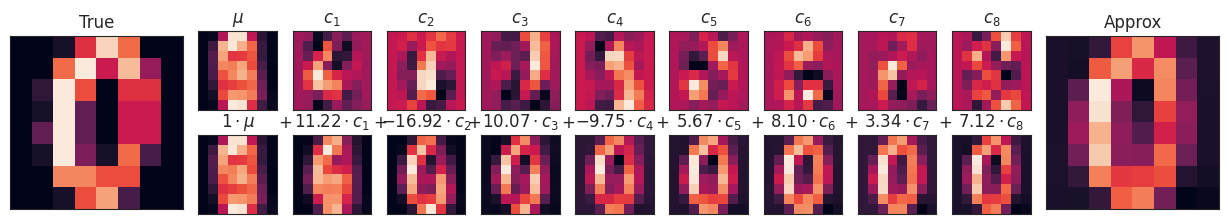

In [ ]:
pca = PCA(n_components=8)
Xproj = pca.fit_transform(digits.data)
fig = plot_pca_components(digits.data[10], Xproj[10],
                          pca.mean_, pca.components_)

Unlike the pixel basis, the PCA basis allows us to recover the key features of the input image with just a mean plus eight components! The amount of each pixel in each component is the corollary of the orientation of the vector in our two-dimensional example. This is the sense in which PCA provides a low-dimensional representation of the data: it discovers a set of basis functions that are more efficient than the native pixel-basis of the input data.

### Choosing the number of components

A vital part of using PCA in practice is the ability to estimate how many components are needed to describe the data. This can be determined by looking at the cumulative explained variance ratio as a function of the number of components:

In [ ]:
pca = PCA().fit(digits.data)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

In [ ]:
pca.explained_variance_ratio_

array([0.148906, 0.136188, 0.117946, 0.0841  , 0.057824, 0.049169,
       0.04316 , 0.036614, 0.033532, 0.030788, 0.023723, 0.022727,
       0.018219, 0.017739, 0.014671, 0.014097, 0.013186, 0.012481,
       0.010177, 0.009056, 0.008895, 0.007971, 0.007675, 0.007229,
       0.006959, 0.005961, 0.005756, 0.005152, 0.004895, 0.004289,
       0.003736, 0.003533, 0.003367, 0.00328 , 0.003083, 0.002938,
       0.002566, 0.002277, 0.002223, 0.002114, 0.001899, 0.001587,
       0.001512, 0.001406, 0.001166, 0.001075, 0.000964, 0.000775,
       0.000557, 0.000404, 0.00021 , 0.000082, 0.000053, 0.000051,
       0.000033, 0.000012, 0.000007, 0.000003, 0.000001, 0.000001,
       0.      , 0.      , 0.      , 0.      ])

In [ ]:
fig = px.line(cumulative_variance)

fig.update_layout(
    xaxis_title='Number of Components',
    yaxis_title='Cumulative Explained Variance',
    yaxis=dict(range=[0, 1])
)

fig.show()

This curve quantifies how much of the total, 64-dimensional variance is contained within the first N components. For example, we see that with the digits the first 10 components contain approximately 75% of the variance, while you need around 50 components to describe close to 100% of the variance.

Here we see that our two-dimensional projection loses a lot of information (as measured by the explained variance) and that we'd need about 20 components to retain 90% of the variance. Looking at this plot for a high-dimensional dataset can help you understand the level of redundancy present in multiple observations.

## PCA as Noise Filtering

PCA can also be used as a filtering approach for noisy data. The idea is this: any components with variance much larger than the effect of the noise should be relatively unaffected by the noise. So if you reconstruct the data using just the largest subset of principal components, you should be preferentially keeping the signal and throwing out the noise.

Let's see how this looks with the digits data. First we will plot several of the input noise-free data:

In [ ]:
def plot_digits(data):
    fig, axes = plt.subplots(4, 10, figsize=(10, 4),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i].reshape(8, 8),
                  cmap='binary', interpolation='nearest',
                  clim=(0, 16))

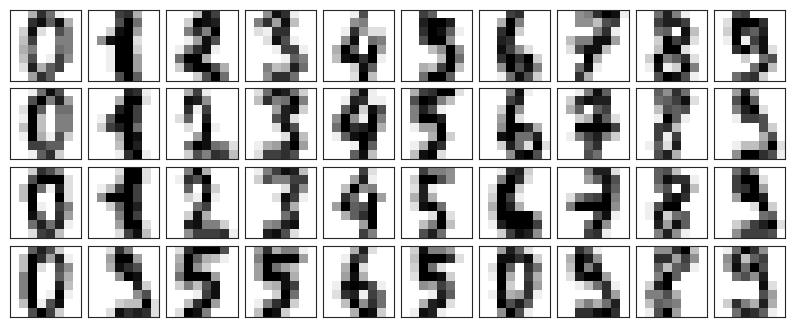

In [ ]:
plot_digits(digits.data)

Now lets add some random noise to create a noisy dataset, and re-plot it:

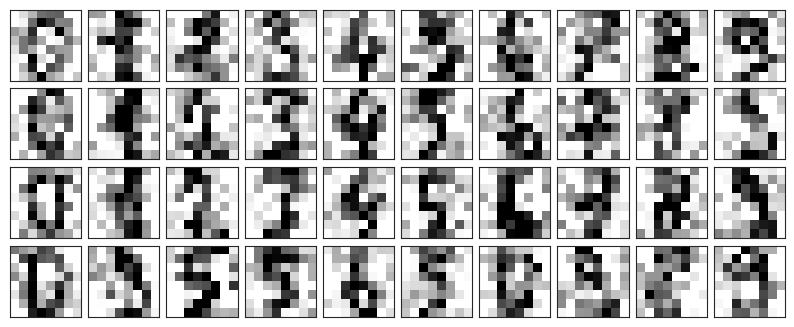

In [ ]:
noisy = np.random.normal(digits.data, 4)
plot_digits(noisy)

It's clear by eye that the images are noisy, and contain random pixels. Let's train a PCA on the noisy data, requesting that the projection preserve 50% of the variance:

In [ ]:
pca = PCA(0.50).fit(noisy)
pca.n_components_

np.int64(12)

Here 50% of the variance amounts to 12 principal components. Now we compute these components, and then use the inverse of the transform to reconstruct the filtered digits:

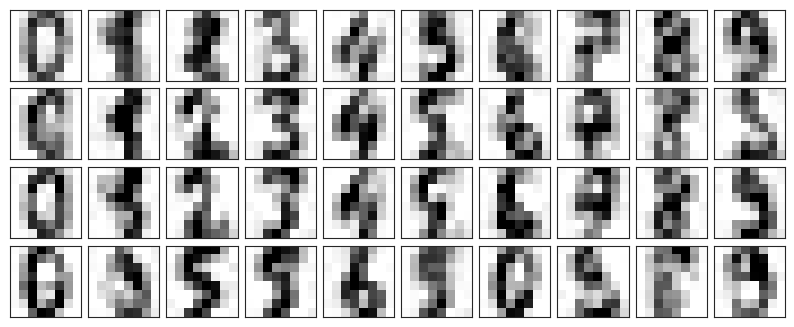

In [ ]:
components = pca.transform(noisy)
filtered = pca.inverse_transform(components)
plot_digits(filtered)

This signal preserving/noise filtering property makes PCA a very useful feature selection routine—for example, rather than training a classifier on very high-dimensional data, you might instead train the classifier on the lower-dimensional representation, which will automatically serve to filter out random noise in the inputs.

## PCA for Facial Data

Let's take a look at the facial recognition problem. We will use the Labeled Faces in the Wild dataset, which consists of several thousand collated photos of various public figures. A fetcher for the dataset is built into Scikit-Learn:

In [ ]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Let's take a look at the principal axes that span this dataset. Because this is a large dataset, we will use `RandomizedPCA` as it contains a randomized method to approximate the first N principal components much more quickly than the [standard](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) PCA estimator, and thus is very useful for high-dimensional data (here, a dimensionality of nearly 3K). We will take a look at the first 150 components:

In [ ]:
pca = PCA(150, svd_solver='randomized')
pca.fit(faces.data)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",150
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'randomized'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomi

In this case, it can be interesting to visualize the images associated with the first several principal components (these components are technically known as "eigenvectors," so these types of images are often called "eigenfaces", and any further field where you analyse these will be eigen-*whatever*). As you can see in this figure, they are as creepy as they sound:

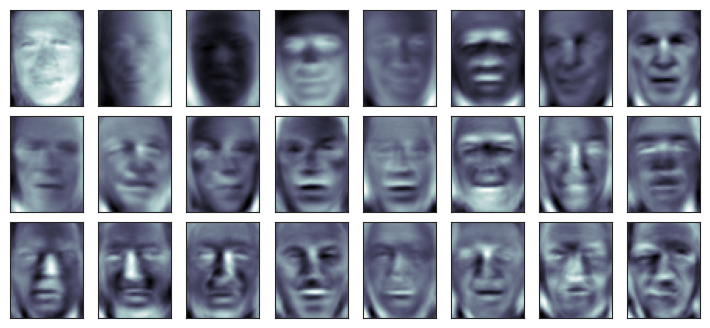

In [ ]:
fig, axes = plt.subplots(3, 8, figsize=(9, 4),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(62, 47), cmap='bone')

The results are very interesting, and give us insight into how the images vary: for example, the first few eigenfaces (from the top left) seem to be associated with the angle of lighting on the face, and later principal vectors seem to be picking out certain features, such as eyes, noses, and lips. Let's take a look at the cumulative variance of these components to see how much of the data information the projection is preserving:

In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

fig = px.line(cumulative_variance)

fig.update_layout(
    xaxis_title='Number of Components',
    yaxis_title='Cumulative Explained Variance',
    yaxis=dict(range=[0, 1])
)

fig.show()

We see that these 150 components account for just over 90% of the variance. That would lead us to believe that using these 150 components, we would recover most of the essential characteristics of the data. To make this more concrete, we can compare the input images with the images reconstructed from these 150 components:

In [ ]:
ca = PCA(150, svd_solver='randomized').fit(faces.data)
components = pca.transform(faces.data)
projected = pca.inverse_transform(components)

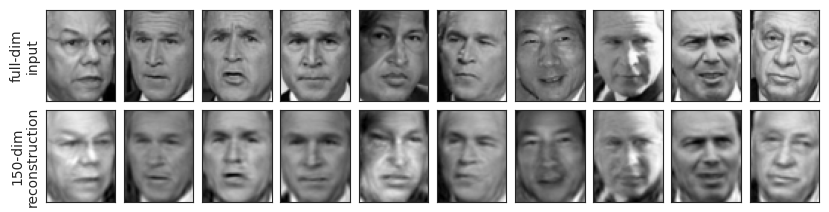

In [ ]:
fig, ax = plt.subplots(2, 10, figsize=(10, 2.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    ax[1, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')
    
ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('150-dim\nreconstruction');

The top row here shows the input images, while the bottom row shows the reconstruction of the images from just 150 of the ~3000 initial features. What this means is that our classification algorithm can be trained on 150-dimensional data rather than 3000-dimensional data, which depending on the particular algorithm we choose, can lead to a much more efficient classification!

Let's experiment with PCA [here](https://setosa.io/ev/principal-component-analysis/)